In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

In [15]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [16]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}


Model: Logistic Regression
Accuracy: 0.7532467532467533

Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



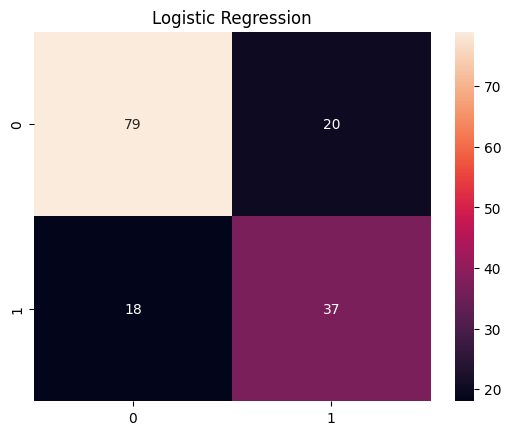


Model: Random Forest
Accuracy: 0.7467532467532467

Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



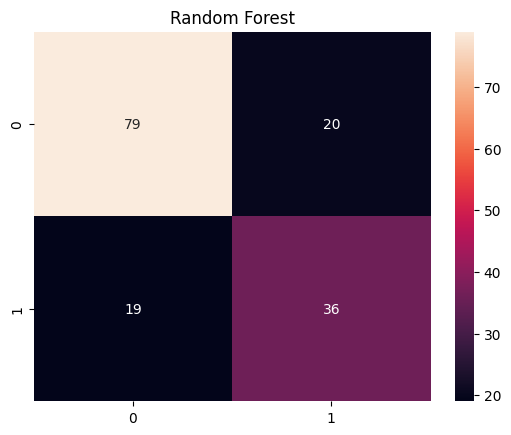


Model: SVM
Accuracy: 0.7337662337662337

Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



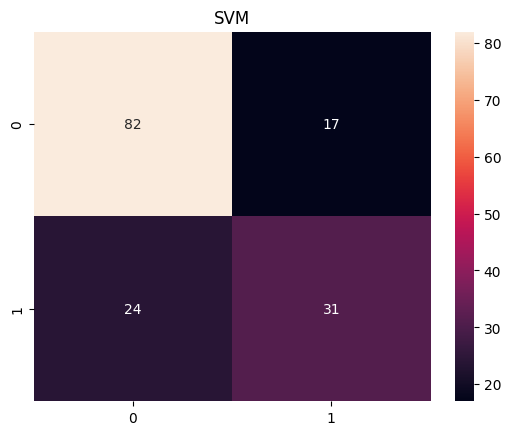

In [20]:
results = {}

for name, model in models.items():
    print("\n====================")
    print("Model:", name)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("\nReport:")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.show()

In [21]:
print("\nFINAL RESULTS")

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


FINAL RESULTS
Logistic Regression: 0.7532
Random Forest: 0.7468
SVM: 0.7338

Best Model: Logistic Regression
